In [1]:
%%HTML

<link rel="stylesheet" href="rise.css"/>

In [26]:
import numpy as np
from scipy.constants import mu_0, epsilon_0
import scipy.special as scf

import numba
from numba.extending import overload, get_cython_function_address
from numba import types
import ctypes

import matplotlib.pyplot as plt
from matplotlib import colors

import sympy as sp
from sympy.integrals.transforms import inverse_laplace_transform, laplace_transform, fourier_transform

# Ground Penetrating Radar
The other end of the spectrum

Topics of the day:
* Going from quasi-static to wave-regime
* The Physical Property (Dielectric Permitivity)
* What do we record?
* How do we record it?

## Making waves

As discussed previously, Maxwell's equations in a homogenous conductive medium reduce to:

$$
\nabla^2 \vec{E} = \mu \sigma \frac{\partial\vec{E}}{\partial t} + \mu\epsilon\frac{\partial^2 \vec{E}}{\partial t^2}
$$

We said that in the quasi-static regime, we ignored the second derivative in time, giving us the diffusion equation.

This formed our basic physics for EM

### In the frequency domain:

For a harmonic planewave, traveling down (in the $-z$ direction), the solution to the above equation was written as:

$$
\vec{E}(t, z) = \vec{E}_0 e^{i(\omega t + kz)}
$$

where the wavenumber was:
$$k^2 = \mu\varepsilon\omega^2 - i\mu\sigma\omega$$

Parameterize $k$ as:

$$
k = k_r - i k_i
$$

Then the real and negative imaginary part of $k$ look like, as a function of the ratio of $\sigma/\varepsilon\omega$

In [3]:
def k_r_func(sigma, mu, eps, omega):
    k_r = (omega
           * np.sqrt(eps * mu/ 2)
           * np.sqrt(np.sqrt(1 + (sigma/(eps * omega))**2) + 1)
          )
    return k_r

def k_i_func(sigma, mu, eps, omega):
    k_i = (omega
           * np.sqrt(eps * mu/ 2)
           * np.sqrt(np.sqrt(1 + (sigma/(eps * omega))**2) - 1)
          )
    return k_i

def k_quasi_func(sigma, mu, eps, omega):
    return np.sqrt(mu * sigma * omega / 2)

def k_r_wave_func(sigma, mu, eps, omega):
    return omega * np.sqrt(mu * eps)

def k_i_wave_func(sigma, mu, eps, omega):
    return sigma/2 * np.sqrt(mu/eps) * np.ones_like(omega)

sigma = 0.01

ratio = np.logspace(-3, 3)
omega = sigma/(epsilon_0 * ratio)
k_r = k_r_func(sigma, mu_0, epsilon_0, omega)
k_i = k_i_func(sigma, mu_0, epsilon_0, omega)

k_quasi = k_quasi_func(sigma, mu_0, epsilon_0, omega)
k_r_wave = k_r_wave_func(sigma, mu_0, epsilon_0, omega)
k_i_wave = k_i_wave_func(sigma, mu_0, epsilon_0, omega)

In [8]:
def do_ratio_plot():
    plt.figure(dpi=200)
    plt.loglog(ratio, k_r, label=r'$k_r$')
    plt.loglog(ratio, k_i, label=r'$k_i$')
    plt.loglog(ratio, k_r_wave, 'C0--', label=r'$k_{r,wave}$')
    plt.loglog(ratio, k_i_wave, 'C1--', label=r'$k_{i,wave}$')
    
    plt.loglog(ratio, k_quasi, 'C2--', label=r'$k_{quasi}$')
    
    plt.legend()
    plt.xlabel(r'$\frac{\sigma}{\epsilon\omega}$')
    plt.ylabel(r'Wavenumber $m^{-1}$')
    xlims = plt.gca().get_xlim()
    print(xlims)
    
    plt.axvspan(50, 1E5, alpha=0.1)
    plt.axvspan(1E-6, 0.285, alpha=0.1, color='C1')
    plt.xlim(*xlims)
    plt.annotate('Quasistatic\nRegime', [8E1,5])
    plt.annotate('Wave Regime', [2E-3,0.5])

(np.float64(0.0005011872336272725), np.float64(1995.2623149688789))


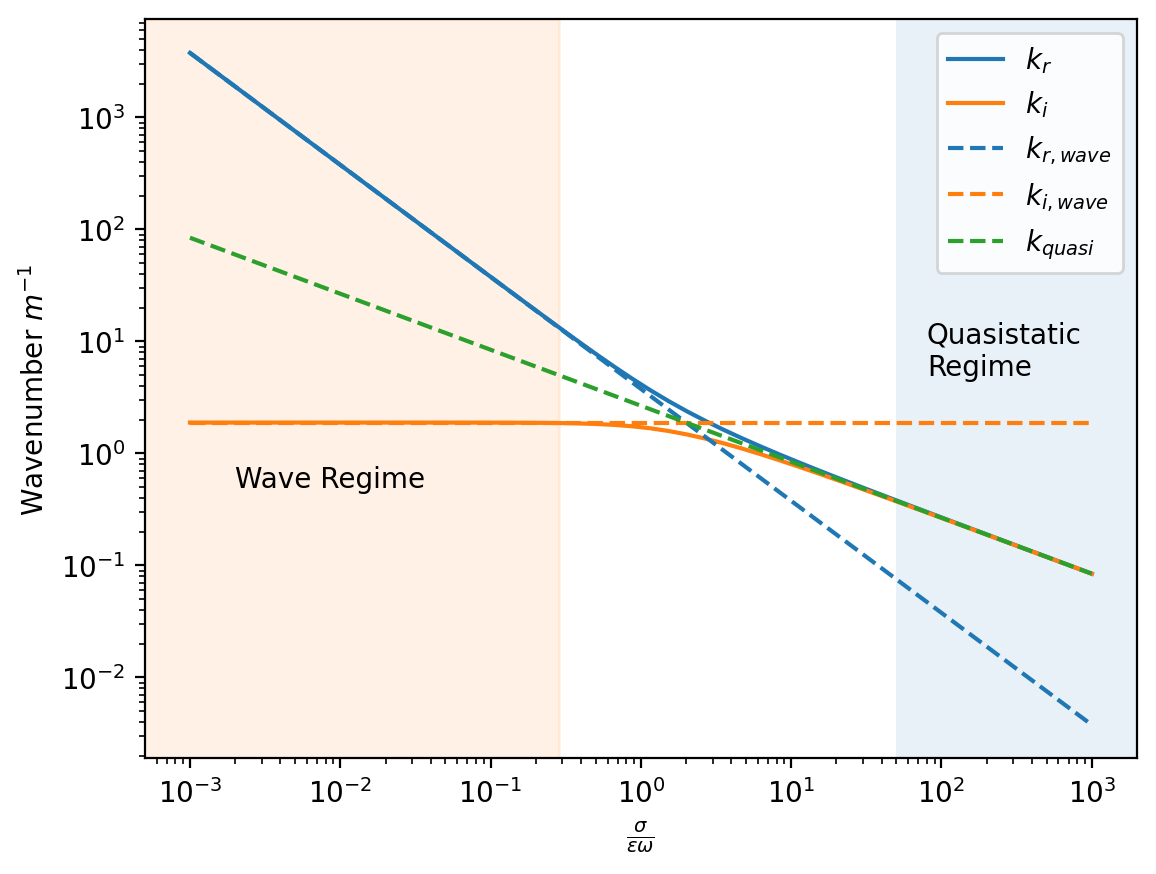

In [9]:
do_ratio_plot()

### Implications in the ferquency domain
The imaginary part of $k$ describes how much quickly the field decays with depth (it was used to find skin depth).

$$d = \frac{1}{\omega} \sqrt{\frac{2}{\varepsilon \mu}}\bigg[ \sqrt{1 + \big(\frac{\sigma}{\varepsilon\omega}\big)^2} - 1\bigg]^{-1/2}$$

Which we said so far, approximates in the quasi-static regime as:

$$
d \approx \sqrt{\frac{2}{\mu \sigma \omega}}
$$

* Low frequencies and low conductivities increase the skin-depth

In the wave regime however, this reduces to:

$$
d \approx \frac{2}{\sigma}\sqrt{\frac{\varepsilon}{\mu}}
$$

* skin depth depends only on the properties of the materials (not the frequency).
* Higher conductivities decrease the skin-depth

The real part of $k$ determines the speed the wave propogates at:

$$v = \frac{\omega}{k_r} = \sqrt\frac{2}{\varepsilon \mu}\left(\sqrt{1 + (\frac{\sigma}{\varepsilon \omega})^2} + 1 \right)^{-\frac{1}{2}}$$

V is a function of $\omega$! (a.k.a. dispersion)

In the quasi-static regime:
$$v_{quasi} \approx \sqrt{\frac{2 \omega}{\sigma \mu}}$$

But in the wave regime:

$$v_{wave} \approx \sqrt{\frac{1}{\mu \varepsilon}}$$

* $v_{wave}$ is **not** dependant on $\omega$

### In the time domain?


* We already have a sense of what this looks like in the quasi-static regime as a function of time (smoke rings)
* We have a sense in frequency-domain where these two regimes split from each other.
* But how does this happen in the time domain?

#### Laplace transform it

You can get the time-domain solution of an impulsive plane wave by inverse laplace transforming the harmonic plane-wave solution:

* It's rather complicated:


\begin{align}
r = |z|/c\\
a = \sigma/(2 \varepsilon) \\
|E|(r, t) = e^{a r} \delta(t-r) + \frac{a z e^{-at}}{c \sqrt{t^2 - r^2}} I_1\bigg[a\sqrt{t^2 - r^2} \bigg]u(t-r)
\end{align}

> If it's been a while, a Laplace transform is just a one-sided in time fourier transform

In [10]:
func_address = get_cython_function_address('scipy.special.cython_special', 'i1e')
func_type = ctypes.CFUNCTYPE(ctypes.c_double, ctypes.c_double)
c_func = func_type(func_address)

@overload(scf.i1e)
def i1e_numba(x):
    if isinstance(x, types.Float):
        def f(x):
            return c_func(x)
        return f

@numba.vectorize(nopython=True)
def impulse_response(t, r, a, c):
    rc = r/c
    #scale = 1/(4 * np.pi * r)
    if t == rc:
        # e^{-a * rc) * delta(t-rc)
        return np.inf
    elif t < rc:
        # t - r/c < 0
        return 0
    else:
        # t - r/c > 0
        sqrt = np.sqrt(t**2 - rc**2)
        v = a * sqrt
        log_part = -a * t + v + np.log(scf.i1e(v))
        out = a * rc * np.exp(log_part)/sqrt
        if out != out:
            # means there was very small (or large) input to the i1e.
            return 0
        else:
            return out

def model_impulse_response(t, z, sigma, eps, mu, E0=1):
    a = sigma/(2 * eps)
    c = 1.0/np.sqrt(mu * eps)
    out = E0 * impulse_response(t, np.abs(z), a, c)
    return out

def wave_position(z, eps, mu):
    return np.abs(z) * np.sqrt(eps * mu)

In [33]:
def plot_em_magnitude(times, positions, sigma=0.1, eps=epsilon_0, mu=mu_0, lognorm=True):
    response = model_impulse_response(times[:, None], positions[None, :], sigma, eps, mu)

    plt.figure(dpi=200)
    ax = plt.gca()
    if lognorm:
        norm = colors.LogNorm()
    else:
        norm = None
    im = ax.pcolormesh(positions, times, response, norm=norm)
    ys = ax.get_ylim()
    xs = ax.get_xlim()
    
    temp = np.r_[positions.min(), 0, positions.max()]
    wave_front = wave_position(temp, eps, mu)
    
    ax.plot(temp, wave_front, color='k')
    ax.set_ylim(ys)
    ax.set_xlim(xs)
    ax.set_xlabel('x (m)')
    ax.set_ylabel('time (s)')

    cb = plt.colorbar(im)
    cb.set_label('|E|')
    

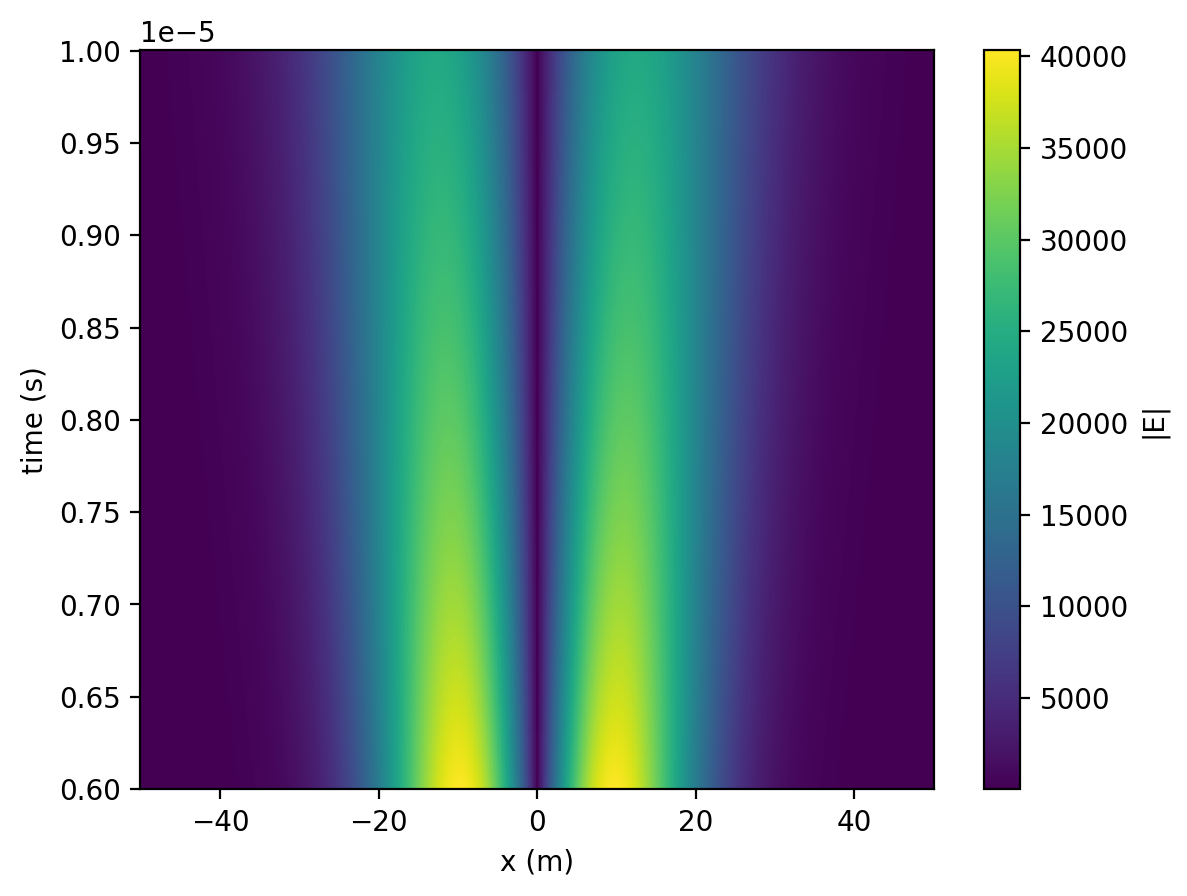

In [41]:
t = np.linspace(6, 10, 1024) * 1E-6 # 6 to 10 micro seconds
x = np.linspace(-0.5, 0.5, 1000)*100  # -50 to 50m

plot_em_magnitude(t, x, lognorm=False)

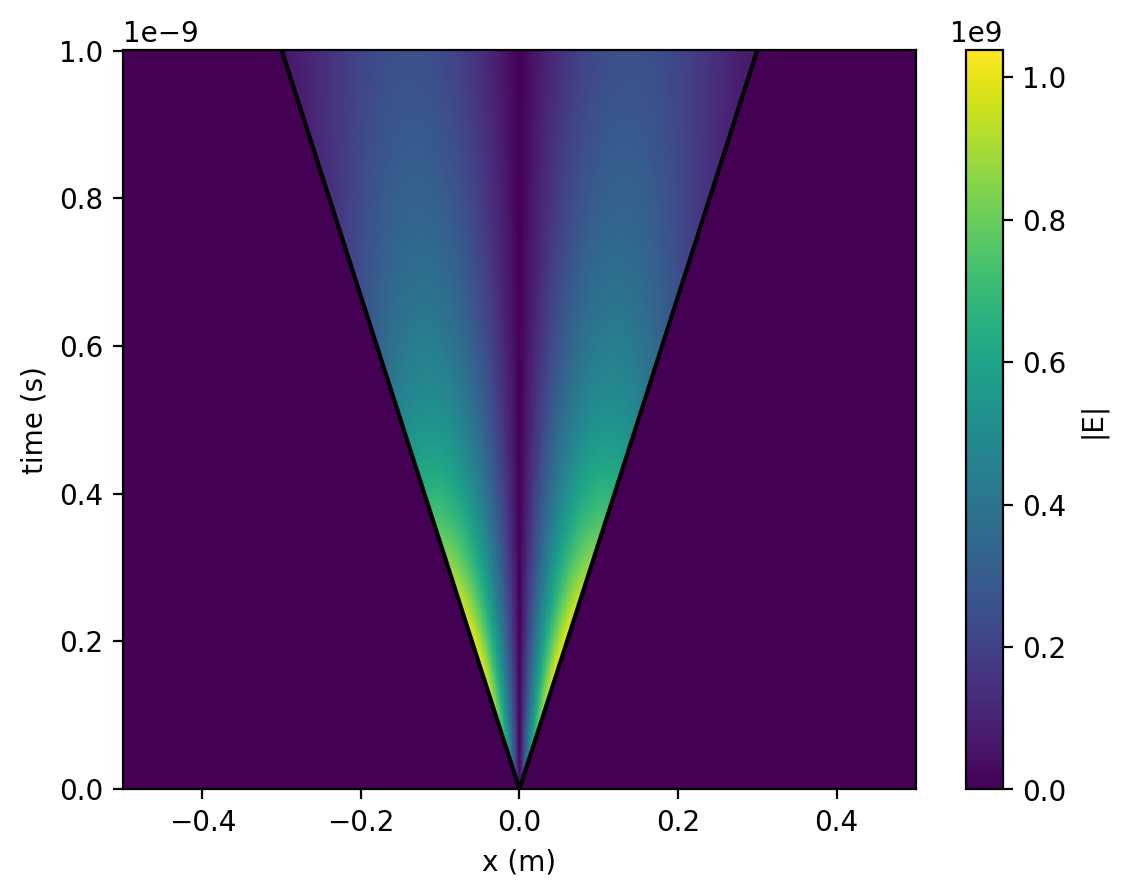

In [43]:
t = np.linspace(0, 1, 1024) * 1E-9 # 0 to 10ns
x = np.linspace(-0.5, 0.5, 1000)*1  # -5 to 5m

plot_em_magnitude(t, x, lognorm=False)

### Dispersion!

Velocity being dependant upon frequency, means that different frequencies travel at different rates.

In the time-domain this looks like ripples on the water after dropping in a rock:
* The two regimes separate in time!

GPR uses a very short pulse, and quckly (on the order of nano-seconds) measures the electric and magnetic fields in time.

## The physical properties:
We've already discussed magnetic permeability and extensively discussed conductivity
* magnetic permeability: tendency for magnetic dipoles to align in a magnetic field
* electrical conductivity: Ease of electrical current flow through a material

### Dielectric Permitivity
In the wave regime:
$$v_{wave} \approx \sqrt{\frac{1}{\mu \varepsilon}}$$

Meaning that the velocity is independant of frequency and dependent on $\mu$ and $\varepsilon$. With most materials having a magnetic permeability near $\mu_0$, that let's us focus on $\varepsilon$, the dielectric permitivity:


<div class=row>
<div class=column>

The tendancy of a material's electrical dipoles to align (and be displaced) in an electrical field.

* Constitutive relationship between electric field ($\vec{E}$), electrical polarization  ($\vec{P}$) and dielectric displacement ($\vec{D}$):
$$
\vec{D} = \varepsilon \vec{E} + \vec{P}
$$

  > (Think $\frac{1}{\mu}\vec{B} = \vec{H} + \vec{M}$)
* Has units of $F/m$ (Farads per meter)

</div>
<div class=column>

![Dielectric](https://em.geosci.xyz/_images/electric_polarization_physics_diagram.png)
</div>

</div>


#### Relative Permittivity
Often you will see dielectric permitivity expressed in its relation to vaccuum permitivity.

$$
\varepsilon_r = \frac{\varepsilon}{\varepsilon_0}
$$

> which is of course unitless

### Material values:
Some values for $\varepsilon_0$ in common materials are:

|Material      |$\varepsilon_r$|$V_{avg}$ (m/ns)|$\sigma$ (ms/m)|Penetration Depth (m)|
---------------|---------------------|----------------------|---------------------|---------------------|
|Air           | 1                   | 0.3                  | 0                   | $\infty$      |
|Fresh Water   | 80                  | 0.033                | 0.5                 | 285                 |
|Sea Water     | 80                  | 0.01                 | 3000                | < 0.1               |
|Ice           | 3 - 4               | 0.16                 | 0.01                | 3000                |
|Dry Sand      | 3 - 5               | 0.15                 | 0.01                | 3200                |
|Saturated Sand| 20 - 30             | 0.06                 | 0.1 - 1             | 145                 |
|Limestone     | 4 - 8               | 0.12                 | 0.5 - 2             | 30                  |
|Shales        | 5 - 15              | 0.09                 | 1 - 100             | 1                   |
|Silts         | 5 - 30              | 0.07                 | 1 - 100             | 1.3                 |
|Clays         | 5 - 40              | 0.06                 | 2 - 1000            | 0.2                 |
|Granite       | 4 - 6               | 0.13                 | 0.01 - 1            | 65                  |
|Anhydrites    | 3 - 4               | 0.13                 | 0.01 - 1            | 55                  |

* Water content has a large impact on dielectric permeability
* Conductivity controls how deep we can penetrate

## The basic theory
<div class=row>
<div class=column>

* Tx antenna generates a short wavelet pulse.
* Travel with a certain speed (determined by the all three physical properties, but mostly $\varepsilon$)
    * Usually expressed in m/ns ($c\approx 0.3$ m/ns) 
* Reflect and Transmit at interfaces between materials of different impedances.
  $$
  \eta = \sqrt{\frac{\mu}{\varepsilon}}
  $$
</div>
<div class=column>

![waves](https://em.geosci.xyz/_images/LayeredEarth.gif)
</div>
</div>

* Refract based on velocity differences (Snell's Law)
* Decrease in amplitide radially due to spreading wavefront
* Loose energy due to conductivity (Also decreases amplitude)

## Applications

* Burried pipes
* Concrete testing (checking for integrity)
* Ice/snow (Avalanche search and rescue)
* Testing Soil conditions
* Geotechical (tunnels)
* Forensic
* Archealogical:

![Jordan](https://em.geosci.xyz/_images/GPR_picture_example.jpg)

* Mars!

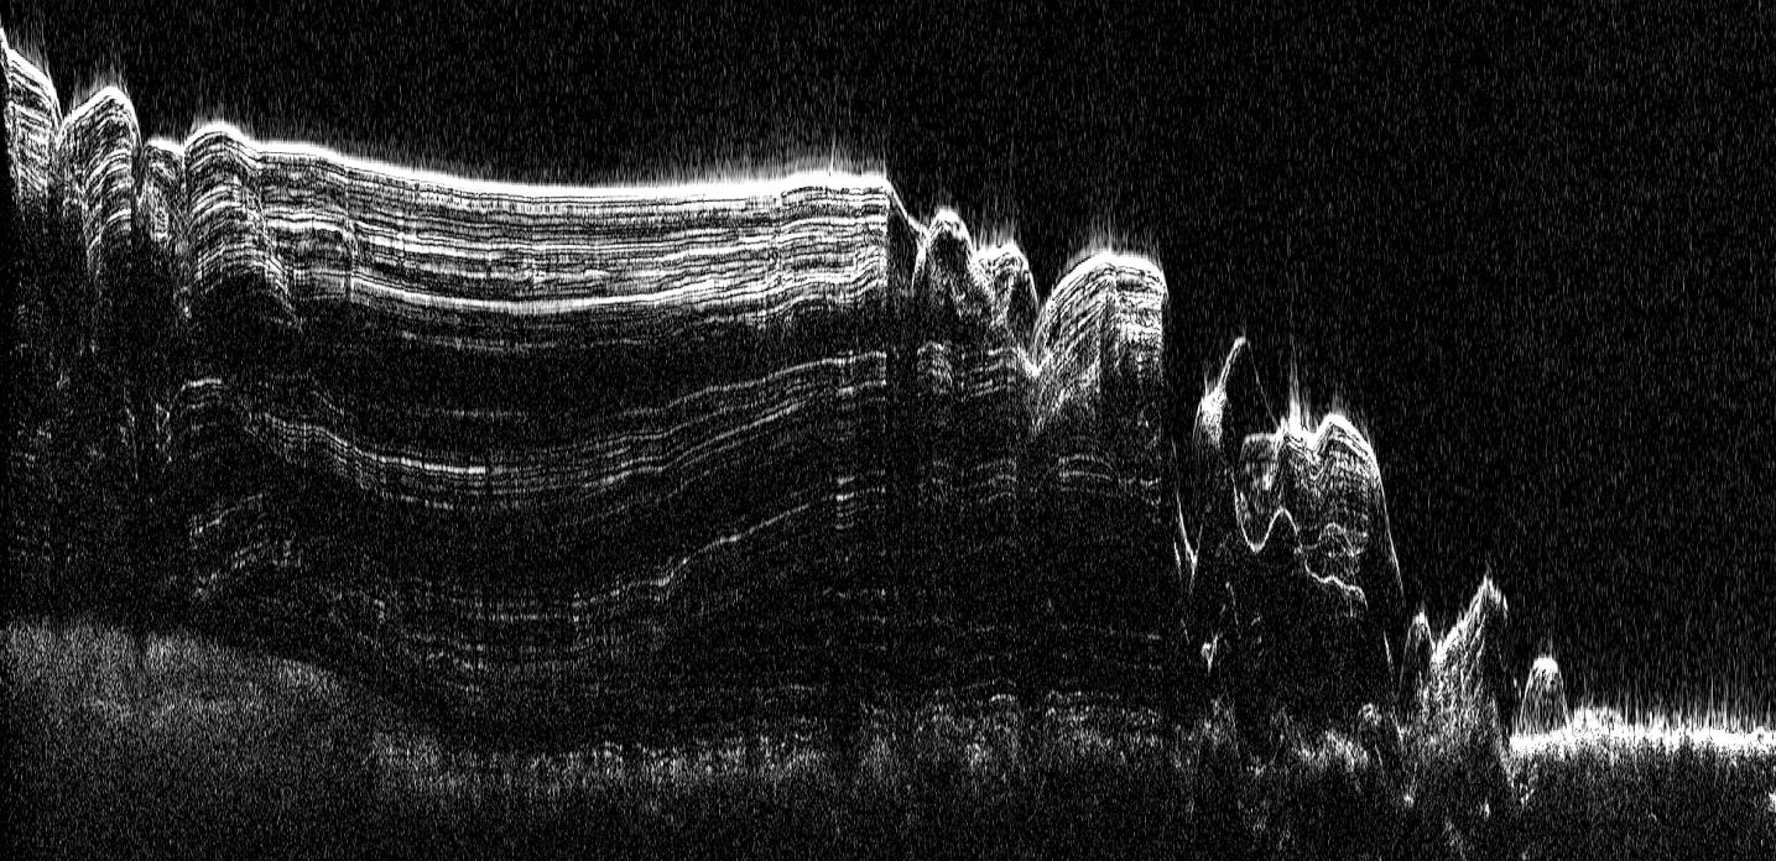

## The data are:
Electric field disturbances at a paricular location as a function of time.